# One reported event, radar, and infrared context

Use an Oklahoma tornado report to verify a bounded nearest-scan selection, open
one radar sweep safely, and plot nearby GOES infrared imagery. This worked case
uses event **1184052**, KTLX, and GOES-16 channel 13. The accompanying manifest
records the three inputs selected during discovery; the cells below repeat the
selection calculation and check that those choices still match the locked inputs.

Requires **usdata v0.9 or later** for the temporal- and sweep-selection APIs and the repository's examples,
radar, and netcdf environments (`just notebooks`). The three source archives total
about 36 MB; an empty-cache restoration downloads them once more. Decoding needs
several hundred MB of memory. Run every cell in order. Saved outputs are a dated
snapshot; retain the manifest, lockfile, and raw bytes for your own analysis.

In [1]:
import gc
import json
import sys
import tempfile
import time
from datetime import UTC, datetime, timedelta, timezone
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import CRS, Geod, Transformer

from usdata import build_query, get, select_by_time
from usdata.providers import load_adapter
from usdata.pull import pull, verify
from usdata.readers import RadarDecodeError

manifest = Path("examples/event-context/dataset.yaml")
if not manifest.is_file():
    manifest = Path("dataset.yaml")
print("Executed UTC:", datetime.now(UTC).isoformat(timespec="seconds"))
print("Python:", sys.version.split()[0])
print({name: version(name) for name in ("usdata", "pandas", "xradar", "xarray", "pyproj")})

Executed UTC: 2026-09-09T03:47:03+00:00
Python: 3.14.7
{'usdata': '0.8.0', 'pandas': '3.0.5', 'xradar': '0.12.0', 'xarray': '2026.7.0', 'pyproj': '3.8.0'}


## Pin and verify source bytes

Storm Events bulk access returns a complete annual archive even for a one-day
query. NCEI can revise older years; the lock pins the creation-date filename and
checksum. Radar and GOES bounds in this manifest equal the discovered scan start.
On later runs, `pull` restores the lock without repeating provider discovery.
The separate listing check below is deliberately live and is not needed merely
to restore an existing analysis.

In [2]:
started = time.perf_counter()
result = pull(manifest)
assert len(result.fetched) == 3
assert verify(manifest) == []
items = {item.asset.dataset_id: item for item in result.fetched}
assert len(items) == 3
print("Pull seconds:", round(time.perf_counter() - started, 2))
print("Total source bytes:", sum(item.provenance.size for item in result.fetched))
print(
    json.dumps(
        [
            {
                "dataset": item.asset.dataset_id,
                "asset": item.asset.id,
                "source": item.provenance.source_url,
                "bytes": item.provenance.size,
                "retrieved_utc": item.provenance.retrieved_at.isoformat(),
                "checksum": item.provenance.checksum,
            }
            for item in result.fetched
        ],
        indent=2,
    )
)

Pull seconds: 4.25
Total source bytes: 36252915
[
  {
    "dataset": "noaa:storm-events",
    "asset": "StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz",
    "source": "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz",
    "bytes": 12693243,
    "retrieved_utc": "2026-09-09T03:47:05.169613+00:00",
    "checksum": "sha256:2070b83eccab041b36360ab73645b9a249c3eefc5b92b5b3fc0cbba4d9fcc09c"
  },
  {
    "dataset": "noaa:nexrad-level2",
    "asset": "KTLX20240507_044053_V06",
    "source": "s3://unidata-nexrad-level2/2024/05/07/KTLX/KTLX20240507_044053_V06",
    "bytes": 19826021,
    "retrieved_utc": "2026-09-09T03:47:06.727613+00:00",
    "checksum": "sha256:0599ac838bd27cb3c79be0eea057229720109e4da03911683602cd50f357133e"
  },
  {
    "dataset": "noaa:goes-abi",
    "asset": "OR_ABI-L2-CMIPC-M6C13_G16_s20241280441173_e20241280443557_c20241280444068.nc",
    "source": "s3://noaa-goes16/ABI-L2-CMIPC/2024/128/04/OR_ABI-L2-C

## Read the report's time convention explicitly

[NCEI event 1184052](https://www.ncei.noaa.gov/stormevents/eventdetails.jsp?id=1184052)
is an EF1 tornado report beginning in Oklahoma County at 22:39 on May 6, 2024.
The [bulk-format reference](https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/Storm-Data-Bulk-csv-Format.pdf)
identifies local standard time and the `CZ_TIMEZONE` offset. This row says
`CST-6`: use **fixed UTC−6**, giving 04:39 UTC on May 7. Applying a regional
zone's daylight-saving offset would shift this case by an hour. Reject an
unreviewed timezone label rather than guessing. Coordinates mark the reported
path start; a report record is not necessarily an independent storm.

In [3]:
columns = [
    "EVENT_ID",
    "EVENT_TYPE",
    "STATE",
    "CZ_NAME",
    "BEGIN_DATE_TIME",
    "CZ_TIMEZONE",
    "BEGIN_LAT",
    "BEGIN_LON",
    "TOR_F_SCALE",
    "SOURCE",
]
frame = items["noaa:storm-events"].open(usecols=columns)
rows = frame.loc[frame.EVENT_ID.eq("1184052")]
assert len(rows) == 1
report = rows.iloc[0]
if report.CZ_TIMEZONE != "CST-6":
    raise ValueError(f"Review source timezone before matching: {report.CZ_TIMEZONE}")
local_time = datetime.strptime(report.BEGIN_DATE_TIME, "%d-%b-%y %H:%M:%S")
event_time = local_time.replace(tzinfo=timezone(timedelta(hours=-6))).astimezone(UTC)
lat, lon = float(report.BEGIN_LAT), float(report.BEGIN_LON)
assert np.isfinite([lat, lon]).all() and -90 <= lat <= 90 and -180 <= lon <= 180
print(report.to_dict())
print("Report start UTC:", event_time.isoformat())
del frame, rows
gc.collect();

{'EVENT_ID': '1184052', 'STATE': 'OKLAHOMA', 'EVENT_TYPE': 'Tornado', 'CZ_NAME': 'OKLAHOMA', 'BEGIN_DATE_TIME': '06-MAY-24 22:39:00', 'CZ_TIMEZONE': 'CST-6', 'SOURCE': 'NWS Storm Survey', 'TOR_F_SCALE': 'EF1', 'BEGIN_LAT': 35.378, 'BEGIN_LON': -97.543}
Report start UTC: 2024-05-07T04:39:00+00:00


## Check the nearest listed scan starts within ±5 minutes

KTLX and GOES-16 C13 are explicit choices for this historical case. Use `select_by_time` to rank each
provider's candidates by absolute start-time difference, breaking ties by asset
ID. Require a match within 300 seconds and compare the winner with the manifest's
fetched asset. The result records the policy, signed offset, and candidate counts;
missing or naive start times raise instead of being skipped. If this fails, investigate changed
source listings/report revisions before editing the manifest and deliberately
resolving a new lock. The time tolerance is an analysis choice, not an SDK default.

This matches **scan starts**, not the exact ray or satellite pixel acquisition
time. Radar volumes and GOES scans span time; nearest starts do not imply
simultaneous measurements or prove a reported tornado's presence. The table also
compares `at_or_before`: this selects a prior **start**, which can still belong
to a scan containing observations acquired after the report time.

In [4]:
matches = []
for dataset_id, params in [
    ("noaa:nexrad-level2", {"site": "KTLX"}),
    ("noaa:goes-abi", {"satellite": 16, "channel": 13}),
]:
    query = build_query(
        start=event_time - timedelta(minutes=5), end=event_time + timedelta(minutes=5), **params
    )
    with load_adapter(get(dataset_id)) as provider:
        candidates = provider.list_assets(query)
    selection = select_by_time(
        candidates, target=event_time, tolerance=timedelta(minutes=5), direction="nearest"
    )
    prior = select_by_time(
        candidates, target=event_time, tolerance=timedelta(minutes=5), direction="at_or_before"
    )
    assert selection.asset is not None, f"No scan start within tolerance: {dataset_id}"
    nearest = selection.asset
    delta = selection.offset_seconds
    assert nearest.id == items[dataset_id].asset.id, "Revisit the manifest selection"
    matches.append(
        {
            "dataset": dataset_id,
            "candidates": selection.candidate_count,
            "eligible": selection.eligible_count,
            "scan_start_utc": nearest.time.start.isoformat(),
            "scan_end_utc": nearest.time.end.isoformat(),
            "start_offset_seconds": delta,
            "prior_start_offset_seconds": prior.offset_seconds,
        }
    )
pd.DataFrame(matches)

,dataset,candidates,eligible,scan_start_utc,scan_end_utc,start_offset_seconds,prior_start_offset_seconds
0,noaa:nexrad-level2,2,2,2024-05-07T04:40:53+00:00,2024-05-07T04:40:53+00:00,113.0,-273.0
1,noaa:goes-abi,2,2,2024-05-07T04:41:17.300000+00:00,2024-05-07T04:43:55.700000+00:00,137.3,-162.7


## Open the first radar sweep and inspect the full-volume limitation

This archive has an interior sweep without an end marker. With xradar 0.12,
later coordinate entries shift, so full-volume decoding is unsafe; even equal
ray counts can hide incorrect coordinate pairing. The SDK checks record alignment
and raises `RadarDecodeError`. The first sweep is unaffected and opens through
`item.open(sweep=0)` with normal flag masking and provenance. No direct decoder
fallback or silent sweep dropping is used.

The full-volume probe below records the guard result; if a future backend repairs
the file, it reports that success instead. It does not suppress unrelated errors.
See [ADR 0011](../../docs/adr/0011-radar-sweep-alignment.md).

In [5]:
radar_item = items["noaa:nexrad-level2"]
try:
    full_volume = radar_item.open()
except RadarDecodeError as error:
    print("Full-volume limitation:", error)
else:
    print("This decoder passed full-volume alignment checks:", full_volume.groups)
    del full_volume
radar = radar_item.open(sweep=0)
sweep = radar["sweep_0"].to_dataset()
assert radar.attrs["usdata"]["sweeps"] == ["sweep_0"]
assert radar.attrs["usdata"]["provenance"]["checksum"] == radar_item.provenance.checksum
print("Sweep dimensions:", dict(sweep.sizes))
print("Elevation degrees:", float(sweep.sweep_fixed_angle))
print("Ray time range:", str(sweep.time.min().values), "to", str(sweep.time.max().values))
nearby = sweep.DBZH.sel(range=slice(None, 100_000))
assert nearby.attrs["units"] == "dBZ"
bearing, _, distance = Geod(ellps="WGS84").inv(
    float(radar.longitude), float(radar.latitude), lon, lat
)
print("Report ground distance from KTLX (km):", round(distance / 1000, 2))

Full-volume limitation: cannot safely decode sweep 14: NEXRAD moment and coordinate records do not agree; select an unaffected sweep explicitly with open(sweep=...) or use another decoder. No sweeps were silently dropped.


Sweep dimensions: {'azimuth': 720, 'range': 1832}
Elevation degrees: 0.4833984375
Ray time range: 2024-05-07T04:40:53.536000000 to 2024-05-07T04:41:09.636999936
Report ground distance from KTLX (km): 24.61


## Locate the report in the GOES fixed grid

Build the geostationary CRS from the source CF projection attributes using
[pyproj](https://pyproj4.github.io/pyproj/stable/build_crs_cf.html), transform the
reported longitude/latitude to projected meters, then divide by perspective
height to recover native scan angles. See NOAA's
[GOES projection guide](https://www.star.nesdis.noaa.gov/atmospheric-composition-training/satellite_data_goes_imager_projection.php).
Check domain coverage before selecting a pixel. Keep only DQF=0 pixels in the
plot; this is a source quality flag, not complete science quality control.

The window below is ±120 km in projection-plane coordinates, **not** a constant
ground-distance radius. The star is the ground projection of the report location;
it is not corrected for cloud-height parallax. Brightness temperature is in K,
and is not surface air temperature or a tornado detector.

In [6]:
scene = items["noaa:goes-abi"].open()
projection = scene.goes_imager_projection.attrs
transform = Transformer.from_crs("EPSG:4326", CRS.from_cf(projection), always_xy=True)
px, py = transform.transform(lon, lat)
height = projection["perspective_point_height"]
sx, sy = px / height, py / height
assert np.isfinite([sx, sy]).all()
assert float(scene.x.min()) <= sx <= float(scene.x.max())
assert float(scene.y.min()) <= sy <= float(scene.y.max())
ix = int(np.abs(scene.x.values - sx).argmin())
iy = int(np.abs(scene.y.values - sy).argmin())
point = scene.isel(x=ix, y=iy)
print(
    "Ground-projected nearest pixel:",
    {
        "x": ix,
        "y": iy,
        "DQF": int(point.DQF),
        "accepted_CMI_K": float(point.CMI) if int(point.DQF) == 0 else None,
    },
)
half_window = 120_000 / height
roi = scene.isel(
    x=np.flatnonzero(abs(scene.x.values - sx) < half_window),
    y=np.flatnonzero(abs(scene.y.values - sy) < half_window),
)
brightness = roi.CMI.where(roi.DQF == 0)
assert brightness.attrs["units"] == "K" and int(brightness.count()) > 0
print("Crop dimensions:", dict(brightness.sizes), "DQF=0 pixels:", int(brightness.count()))

Ground-projected nearest pixel: {'x': 861, 'y': 540, 'DQF': 0, 'accepted_CMI_K': 209.9456024169922}
Crop dimensions: {'y': 120, 'x': 120} DQF=0 pixels: 14400


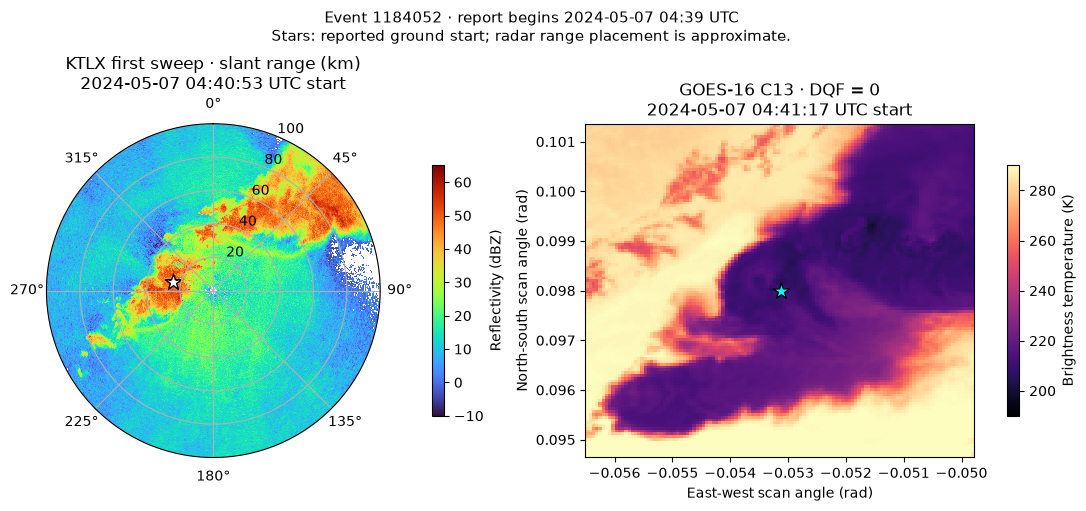

In [7]:
fig = plt.figure(figsize=(11, 5), layout="constrained")
ax_radar = fig.add_subplot(121, projection="polar")
ax_goes = fig.add_subplot(122)
mesh = ax_radar.pcolormesh(
    np.deg2rad(nearby.azimuth.values),
    nearby.range.values / 1000,
    nearby.values.T,
    cmap="turbo",
    shading="auto",
    vmin=-10,
    vmax=65,
)
ax_radar.scatter(
    np.deg2rad(bearing), distance / 1000, marker="*", s=150, c="white", edgecolors="black"
)
ax_radar.set_theta_zero_location("N")
ax_radar.set_theta_direction(-1)
ax_radar.set_ylim(0, 100)
ax_radar.set_title("KTLX first sweep · slant range (km)\n2024-05-07 04:40:53 UTC start")
fig.colorbar(mesh, ax=ax_radar, label="Reflectivity (dBZ)", shrink=0.75)
mesh = ax_goes.pcolormesh(
    brightness.x, brightness.y, brightness, cmap="magma", shading="auto", vmin=190, vmax=290
)
ax_goes.scatter(sx, sy, marker="*", s=150, c="cyan", edgecolors="black")
ax_goes.set(
    xlabel="East-west scan angle (rad)",
    ylabel="North-south scan angle (rad)",
    title="GOES-16 C13 · DQF = 0\n2024-05-07 04:41:17 UTC start",
)
fig.colorbar(mesh, ax=ax_goes, label="Brightness temperature (K)", shrink=0.75)
fig.suptitle(
    "Event 1184052 · report begins 2024-05-07 04:39 UTC\n"
    "Stars: reported ground start; radar range placement is approximate.",
    fontsize=11,
)
plt.show()
plt.close(fig)
del radar, sweep, nearby, scene, roi, brightness, point
gc.collect();

Radar radial range is slant distance; the plotted star uses approximate ground
distance/bearing, not a beam-height calculation. These panels supply storm context
at nearby times. They do not establish tornadogenesis, causation, or exact
collocation. A stronger study needs multiple times, radar beam geometry,
cloud-parallax treatment, additional moments and quality control, and independent
report review. Temporal ranking uses the shared pure helper; report interpretation, source-time
conversion, site choice, and projection choices remain explicit in this notebook.

## Exercise both restoration paths

A second pull should use verified cached bytes. A separate temporary empty cache
must restore all three exact locked assets without provider re-resolution. This
checks the reproducibility mechanism today; upstream can still remove old files,
so preserve your own source archives. The temporary restoration copy is removed
after verification; the normal cache, manifest, and lock remain available.

In [8]:
again = pull(manifest)
assert again.from_lockfile and all(item.from_cache for item in again.fetched)
assert verify(manifest) == []
with tempfile.TemporaryDirectory(prefix="usdata-event-restore-") as directory:
    started = time.perf_counter()
    restored = pull(manifest, root=Path(directory))
    assert restored.from_lockfile and not any(item.from_cache for item in restored.fetched)
    assert verify(manifest, root=Path(directory)) == []
    assert [item.provenance.checksum for item in restored.fetched] == [
        item.provenance.checksum for item in result.fetched
    ]
    print("Empty-cache restoration seconds:", round(time.perf_counter() - started, 2))
print("All three inputs verified; cached and empty-cache locked restoration passed.")

Empty-cache restoration seconds: 3.09
All three inputs verified; cached and empty-cache locked restoration passed.
